In [36]:
# Option A: Simple install
!pip install requests pandas matplotlib # talib tushare

In [37]:
# import talib
import pandas as pd
import matplotlib.pyplot as plt
# import tushare as ts
import os
# import akshare as ak
# import yfinance as yf
# df = yf.download("000001.SZ", start="2025-01-01", end="2025-05-13")

In [38]:
import akshare as ak

# Create folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# --------------------------
# Test 1: Get daily data
# --------------------------
# Use the correct function for A-share daily data
df = ak.stock_zh_a_hist(
    symbol="000001",          # Stock code
    period="daily",           # Daily frequency
    start_date="20250101",    # Format: YYYYMMDD
    end_date="20250513",
    adjust=""                 # "" = no adjustment, "hfq" = post-rights, "qfq" = pre-rights
)

# --------------------------
# Fix column names to match your original Tushare format
# --------------------------
df = df.rename(columns={
    "日期": "trade_date",
    "开盘": "open",
    "最高": "high",
    "最低": "low",
    "收盘": "close",
    "成交量": "vol"
})

# Keep only the columns you need
df = df[["trade_date", "open", "high", "low", "close", "vol"]]

# Sort by date (oldest first, same as your original code)
df["trade_date"] = pd.to_datetime(df["trade_date"])
df = df.sort_values("trade_date").reset_index(drop=True)

# Save to CSV
df.to_csv("data/000001.SZ.csv", index=False)

# Show result
print("✅ Data fetched successfully!")
print(df.head())
print(f"\nTotal rows: {len(df)}")

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

✅ Data ready:
Price  trade_date       open       high        low      close        vol
Ticker             000001.SZ  000001.SZ  000001.SZ  000001.SZ  000001.SZ
0      2025-01-02  10.784818  10.821596  10.472215  10.508992  181959699
1      2025-01-03  10.518186  10.610129  10.444632  10.463021  115468044
2      2025-01-06  10.463020  10.554961  10.315913  10.518185  108553630
3      2025-01-07  10.499797  10.600933  10.453826  10.582545   74786288
4      2025-01-08  10.573351  10.692876  10.481408  10.573351  106238601


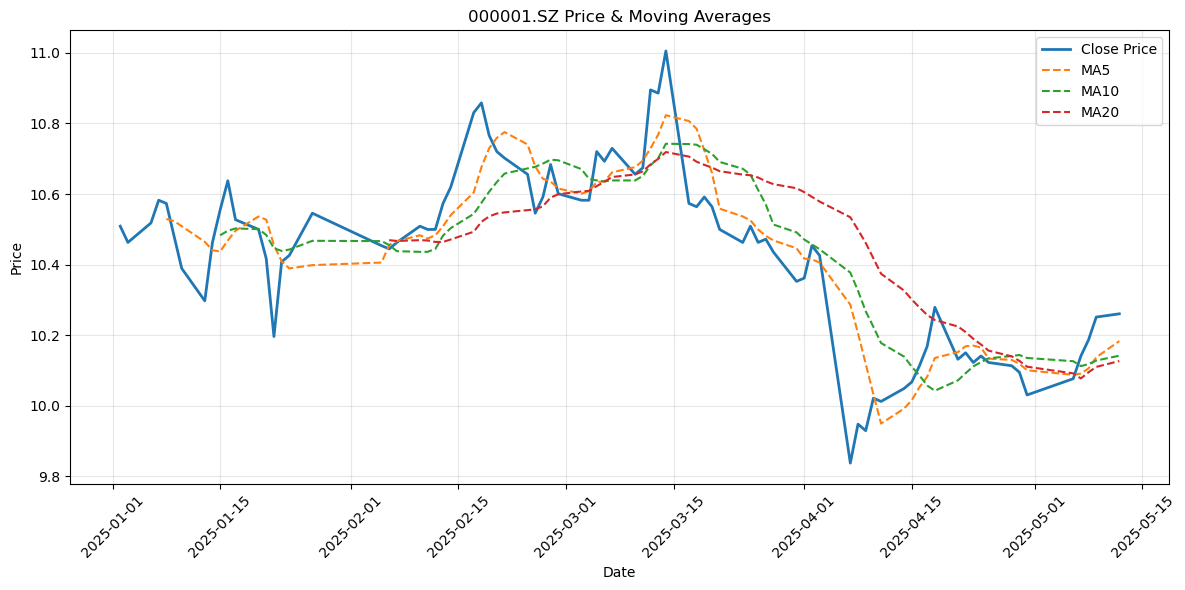

In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Ensure folder exists
os.makedirs("data", exist_ok=True)

# --------------------------
# 1. Fetch data from YFinance
# --------------------------
df = yf.download(
    tickers="000001.SZ",
    start="2025-01-01",
    end="2025-05-13",
    progress=False
)

# Clean and format to match your standard
df = df.reset_index()
df = df.rename(columns={
    "Date": "trade_date",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Volume": "vol"
})

# Keep only needed columns
df = df[["trade_date", "open", "high", "low", "close", "vol"]]
df["trade_date"] = pd.to_datetime(df["trade_date"])
df = df.sort_values("trade_date").reset_index(drop=True)

# Save to CSV
df.to_csv("data/000001.SZ.csv", index=False)
print("✅ Data ready:")
print(df.head())

# --------------------------
# 2. Calculate Moving Averages
# --------------------------
df["MA5"] = df["close"].rolling(window=5).mean()
df["MA10"] = df["close"].rolling(window=10).mean()
df["MA20"] = df["close"].rolling(window=20).mean()

# --------------------------
# 3. Plot Price + MAs
# --------------------------
plt.figure(figsize=(12, 6))
plt.plot(df["trade_date"], df["close"], label="Close Price", linewidth=2)
plt.plot(df["trade_date"], df["MA5"], label="MA5", linestyle="--")
plt.plot(df["trade_date"], df["MA10"], label="MA10", linestyle="--")
plt.plot(df["trade_date"], df["MA20"], label="MA20", linestyle="--")

plt.title("000001.SZ Price & Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()